# Flight Disruption — Exploratory Data Analysis

**Goal.** Understand what drives U.S. domestic flight disruptions, as the foundation for a delay-prediction model.

**Data.** 10.9 million flights across the 40 busiest U.S. airports (early 2023 – mid 2026), each joined to hourly weather at both its **origin** (departure) and **destination** (arrival) airport.

**Target.** A flight counts as **"disrupted"** if it **arrives 15+ minutes late or is cancelled** (diverted flights are excluded). Overall, **23.5%** of flights are disrupted — the baseline every chart below compares against.

### How to read the charts
- Bars or points show the **disruption rate** — the share of flights disrupted within a group.
- The **dashed line** marks the 23.5% overall average.
- **Error bars** are 95% confidence intervals: short bars mean the estimate is solid; long bars mean few flights, so read with caution.
- **"Lift"** (in the printed tables) is a group's rate ÷ the 23.5% average — e.g. lift 2.0 means twice as disruption-prone as average.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def find_project_root(markers=("requirements.txt", ".git")):
    # Walk up from the current directory to the repo root so paths resolve
    # whether this runs from the repo root or from inside notebooks/.
    here = Path.cwd().resolve()
    for parent in (here, *here.parents):
        if any((parent / m).exists() for m in markers):
            return parent
    raise FileNotFoundError(f"Project root not found above {here}")

PROJECT_ROOT = find_project_root()
DATA_PATH    = PROJECT_ROOT / "data" / "processed" / "flights_weather.parquet"
TARGET_COL   = "disrupted"

def wilson_ci(k, n, z=1.96):
    # 95% confidence interval for a proportion (k of n).
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    den = 1 + z**2 / n
    c = (p + z**2 / (2*n)) / den
    h = z * np.sqrt(p*(1-p)/n + z**2 / (4*n**2)) / den
    return (c - h, c + h)

# Overall disruption rate — the baseline every chart compares against.
base_rate = pd.read_parquet(DATA_PATH, columns=[TARGET_COL])[TARGET_COL].mean()

def add_ci_lift(t):
    # Attach a Wilson 95% CI and lift-vs-baseline to a table with rate / k / n.
    ci = [wilson_ci(k, n) for k, n in zip(t["k"], t["n"])]
    t["ci_low"], t["ci_high"] = [c[0] for c in ci], [c[1] for c in ci]
    t["lift"] = t["rate"] / base_rate
    return t

print(f"Loaded. Overall disruption rate (baseline): {base_rate:.1%}")

Loaded. Overall disruption rate (baseline): 23.5%


## 1. Weather

Weather is the obvious primary suspect for disruptions. We look at snow and wind, and at whether the weather at the **departure** airport matters more than at the **arrival** airport.

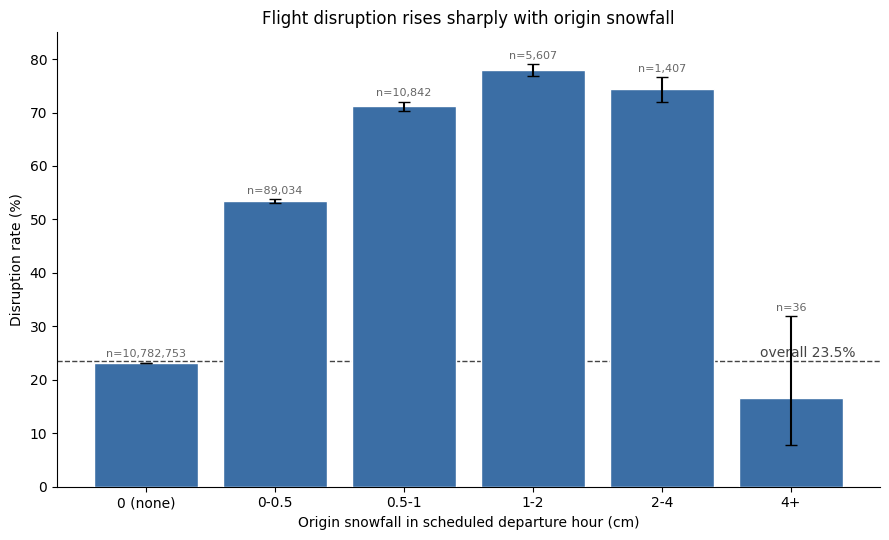

In [2]:
SNOW = "snowfall_orig"
df = pd.read_parquet(DATA_PATH, columns=[SNOW, TARGET_COL])

bins   = [-0.01, 0.0, 0.5, 1.0, 2.0, 4.0, np.inf]
labels = ["0 (none)", "0-0.5", "0.5-1", "1-2", "2-4", "4+"]
df["bucket"] = pd.cut(df[SNOW], bins, labels=labels)

g = add_ci_lift(df.groupby("bucket", observed=True)[TARGET_COL]
                  .agg(rate="mean", k="sum", n="count"))

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(g)); rates = g["rate"].to_numpy() * 100
yerr = np.vstack([(g["rate"]-g["ci_low"]).to_numpy(), (g["ci_high"]-g["rate"]).to_numpy()]) * 100
ax.bar(x, rates, yerr=yerr, capsize=4, color="#3b6ea5", edgecolor="white", zorder=3)
ax.axhline(base_rate*100, ls="--", lw=1, color="#444", zorder=2)
ax.text(len(g)-0.5, base_rate*100+0.8, f"overall {base_rate*100:.1f}%", ha="right", color="#444")
tops = g["ci_high"].to_numpy() * 100
for xi, (top, n) in enumerate(zip(tops, g["n"])):
    ax.text(xi, top+0.7, f"n={n:,}", ha="center", va="bottom", fontsize=8, color="#666")
ax.set_xticks(x); ax.set_xticklabels(g.index)
ax.set_xlabel("Origin snowfall in scheduled departure hour (cm)")
ax.set_ylabel("Disruption rate (%)")
ax.set_title("Flight disruption rises sharply with origin snowfall")
ax.set_ylim(0, max(tops)+6)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout(); plt.show()

**Snow has a powerful effect.** Disruption climbs steeply with snowfall at the departure airport from the 23% baseline up to roughly **78%** in active snow, about **3.3× the average**.

*A caveat:* the "4+ cm" bar rests on only 36 flights (note its tiny count and wide error bar). Digging in, those turned out to be a handful of unusual mild-season snow hours rather than a real pattern, so we fold it into a reliable **"2+"** group in the next chart rather than trust it.

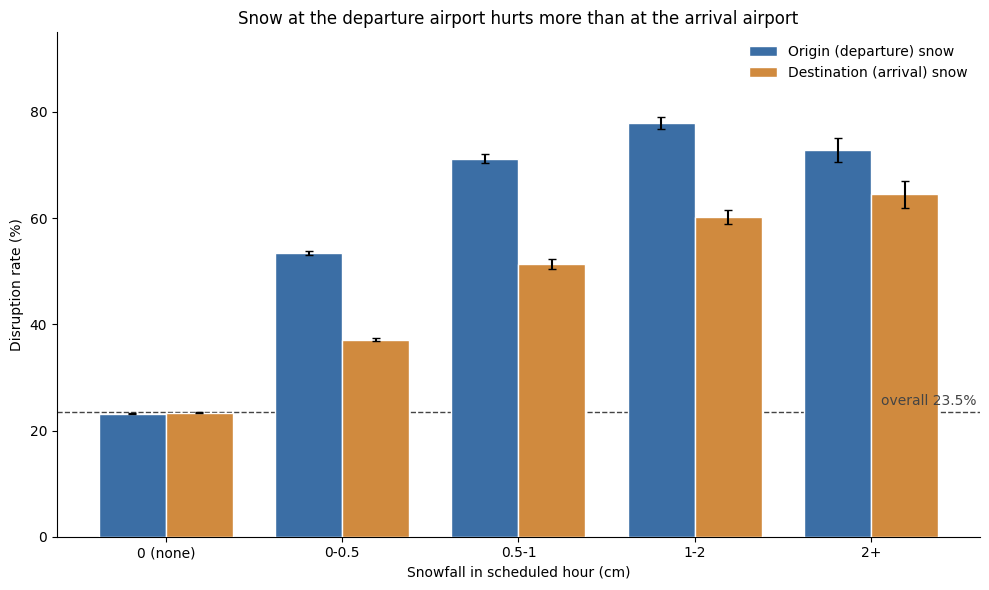

In [3]:
d = pd.read_parquet(DATA_PATH, columns=["snowfall_orig", "snowfall_dest", TARGET_COL])
BINS   = [-0.01, 0.0, 0.5, 1.0, 2.0, np.inf]
LABELS = ["0 (none)", "0-0.5", "0.5-1", "1-2", "2+"]

def snow_table(col):
    t = (pd.DataFrame({"target": d[TARGET_COL], "bucket": pd.cut(d[col], BINS, labels=LABELS)})
         .groupby("bucket", observed=True)["target"].agg(rate="mean", k="sum", n="count"))
    return add_ci_lift(t)

orig, dest = snow_table("snowfall_orig"), snow_table("snowfall_dest")

fig, ax = plt.subplots(figsize=(10, 6))
x, w = np.arange(len(LABELS)), 0.38
def draw(off, tbl, color, label):
    rates = tbl["rate"].to_numpy() * 100
    yerr = np.vstack([(tbl["rate"]-tbl["ci_low"]).to_numpy(), (tbl["ci_high"]-tbl["rate"]).to_numpy()]) * 100
    ax.bar(x+off, rates, w, yerr=yerr, capsize=3, color=color, edgecolor="white", label=label, zorder=3)
draw(-w/2, orig, "#3b6ea5", "Origin (departure) snow")
draw(+w/2, dest, "#d08a3e", "Destination (arrival) snow")
ax.axhline(base_rate*100, ls="--", lw=1, color="#444", zorder=2)
ax.text(len(LABELS)-0.4, base_rate*100+1.2, f"overall {base_rate*100:.1f}%", ha="right", color="#444")
ax.set_xticks(x); ax.set_xticklabels(LABELS)
ax.set_xlabel("Snowfall in scheduled hour (cm)")
ax.set_ylabel("Disruption rate (%)")
ax.set_title("Snow at the departure airport hurts more than at the arrival airport")
ax.legend(frameon=False); ax.set_ylim(0, 95)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout(); plt.show()

**Departure-airport snow hurts more than arrival-airport snow.** At every snow level, snow at the origin (blue) disrupts more than the same snow at the destination (orange). The likely reason is **de-icing**. Planes must be sprayed to clear ice and snow *before takeoff*, a time cost that exists only on the departure side. A snowy arrival airport is more forgiving (planes can slow down or be re-sequenced on approach). One caveat: badly snowed-in destinations cause *diversions*, which we excluded, so the destination effect shown here is a floor — its true impact is somewhat larger.

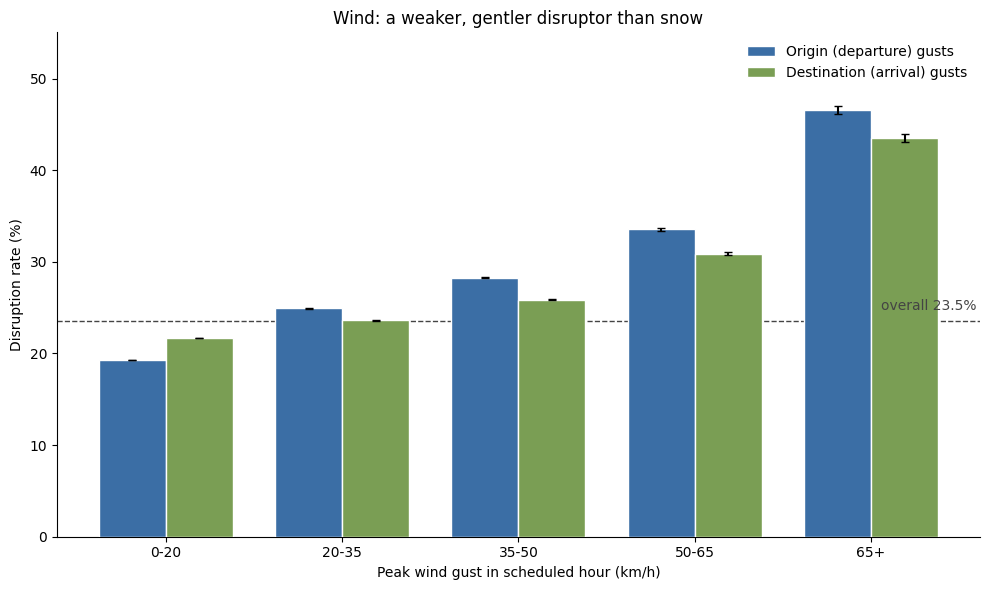

In [4]:
GUST_O, GUST_D = "wind_gusts_10m_orig", "wind_gusts_10m_dest"
d = pd.read_parquet(DATA_PATH, columns=[GUST_O, GUST_D, TARGET_COL])
BINS   = [-0.1, 20, 35, 50, 65, np.inf]
LABELS = ["0-20", "20-35", "35-50", "50-65", "65+"]

def gust_table(col):
    t = (pd.DataFrame({"target": d[TARGET_COL], "bucket": pd.cut(d[col], BINS, labels=LABELS)})
         .groupby("bucket", observed=True)["target"].agg(rate="mean", k="sum", n="count"))
    return add_ci_lift(t)

og, dg = gust_table(GUST_O), gust_table(GUST_D)

fig, ax = plt.subplots(figsize=(10, 6))
x, w = np.arange(len(LABELS)), 0.38
def draw(off, tbl, color, label):
    rates = tbl["rate"].to_numpy() * 100
    yerr = np.vstack([(tbl["rate"]-tbl["ci_low"]).to_numpy(), (tbl["ci_high"]-tbl["rate"]).to_numpy()]) * 100
    ax.bar(x+off, rates, w, yerr=yerr, capsize=3, color=color, edgecolor="white", label=label, zorder=3)
draw(-w/2, og, "#3b6ea5", "Origin (departure) gusts")
draw(+w/2, dg, "#7a9e54", "Destination (arrival) gusts")
ax.axhline(base_rate*100, ls="--", lw=1, color="#444", zorder=2)
ax.text(len(LABELS)-0.4, base_rate*100+1.2, f"overall {base_rate*100:.1f}%", ha="right", color="#444")
ax.set_xticks(x); ax.set_xticklabels(LABELS)
ax.set_xlabel("Peak wind gust in scheduled hour (km/h)")
ax.set_ylabel("Disruption rate (%)")
ax.set_title("Wind: a weaker, gentler disruptor than snow")
ax.legend(frameon=False)
ax.set_ylim(0, max(og["ci_high"].max(), dg["ci_high"].max()) * 100 + 8)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout(); plt.show()

**Wind is a weaker disruptor than snow.** Even gale-force gusts (65+ km/h) only push disruption to 47%, about 2× the average, versus snow's 3×, and the rise is a smooth ramp rather than a cliff. Notice the departure-vs-arrival gap nearly vanishes here, unlike snow. That fits the de-icing theory: wind carries no departure-only penalty, so neither end has a special disadvantage.

## 2. The aircraft and the clock

The biggest non-weather drivers come from how airlines operate: a single plane flies many trips in a day, and delays pile up as the day goes on.

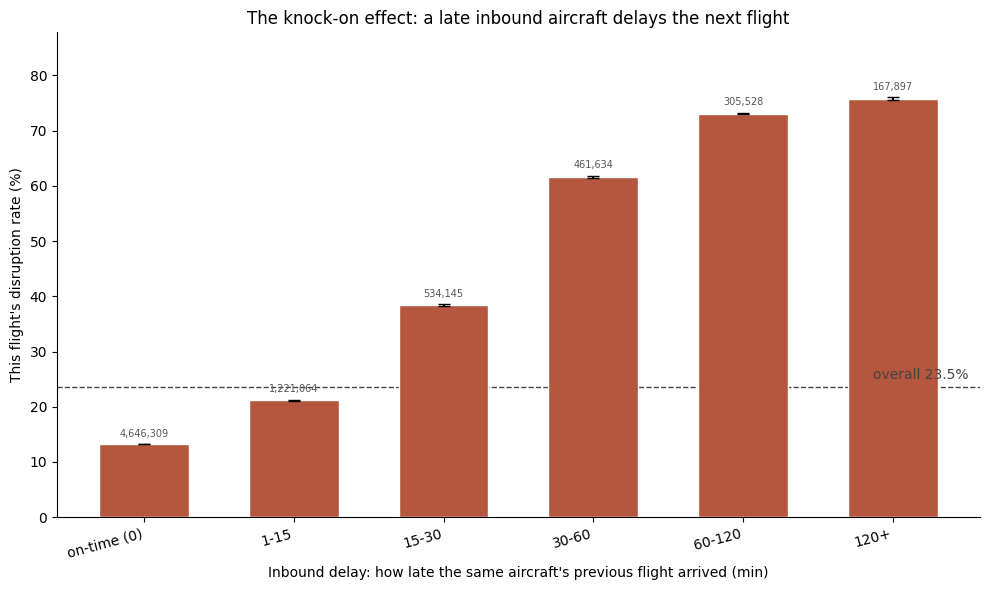

In [5]:
cols = ["Tail_Number", "dep_hour_utc", "arr_hour_utc", "CRSDepTime", "ArrDelayMinutes", TARGET_COL]
d = pd.read_parquet(DATA_PATH, columns=cols)
d = d[d["Tail_Number"].notna() & (d["Tail_Number"].astype(str).str.strip() != "")].copy()
d["dep_hour_utc"] = pd.to_datetime(d["dep_hour_utc"])
d["arr_hour_utc"] = pd.to_datetime(d["arr_hour_utc"])

# Put each aircraft's flights in time order, then read off its previous leg.
d = d.sort_values(["Tail_Number", "dep_hour_utc", "CRSDepTime"])
gb = d.groupby("Tail_Number", sort=False)
d["prev_arr_delay"] = gb["ArrDelayMinutes"].shift(1)          # inbound delay (min)
d["prev_arr_hour"]  = gb["arr_hour_utc"].shift(1)
d["gap_h"] = (d["dep_hour_utc"] - d["prev_arr_hour"]).dt.total_seconds() / 3600

# Keep genuine same-day turnarounds (a real inbound leg, gap within a day).
turns = d[d["prev_arr_delay"].notna() & d["gap_h"].between(0, 8)].copy()
BINS   = [-np.inf, 0, 15, 30, 60, 120, np.inf]
LABELS = ["on-time (0)", "1-15", "15-30", "30-60", "60-120", "120+"]
turns["inbound"] = pd.cut(turns["prev_arr_delay"], BINS, labels=LABELS)

t = add_ci_lift(turns.groupby("inbound", observed=True)[TARGET_COL]
                     .agg(rate="mean", k="sum", n="count"))

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(t)); rates = t["rate"].to_numpy() * 100
yerr = np.vstack([(t["rate"]-t["ci_low"]).to_numpy(), (t["ci_high"]-t["rate"]).to_numpy()]) * 100
ax.bar(x, rates, 0.6, yerr=yerr, capsize=4, color="#b5563f", edgecolor="white", zorder=3)
ax.axhline(base_rate*100, ls="--", lw=1, color="#444", zorder=2)
ax.text(len(t)-0.5, base_rate*100+1.5, f"overall {base_rate*100:.1f}%", ha="right", color="#444")
for xi, (top, n) in enumerate(zip(t["ci_high"]*100, t["n"])):
    ax.text(xi, top+1.0, f"{n:,}", ha="center", va="bottom", fontsize=7, color="#555")
ax.set_xticks(x); ax.set_xticklabels(t.index, rotation=15, ha="right")
ax.set_xlabel("Inbound delay: how late the same aircraft's previous flight arrived (min)")
ax.set_ylabel("This flight's disruption rate (%)")
ax.set_title("The knock-on effect: a late inbound aircraft delays the next flight")
ax.set_ylim(0, max(rates)+12)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout(); plt.show()

**The single strongest signal** Each physical aircraft flies a chain of flights through the day. If the plane arrives late from its **previous** trip (its "inbound delay"), the next flight is far more likely to be disrupted, from just **13%** when the inbound plane was on time, up to **76%** when it was 2+ hours late. Small inbound delays (under 15 min) get absorbed by the scheduled gap between flights; past ~30 minutes that buffer is gone and the delay cascades forward.

*Important for modelling:* in live prediction you might not yet know whether the inbound plane has landed, so this feature must be used carefully to avoid "peeking" at information the model wouldn't really have.

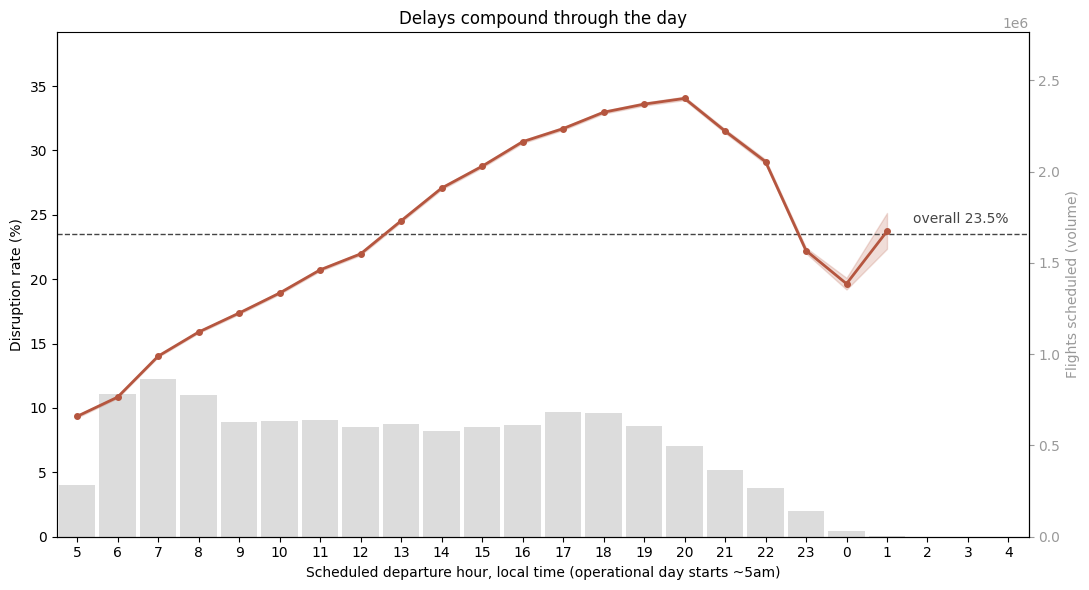

In [6]:
h = pd.read_parquet(DATA_PATH, columns=["CRSDepTime", TARGET_COL])
h = h[h["CRSDepTime"].notna()].copy()
h["hour"] = (h["CRSDepTime"].astype(int) // 100) % 24   # local hour; 2400 -> 0

t = add_ci_lift(h.groupby("hour")[TARGET_COL].agg(rate="mean", k="sum", n="count").reindex(range(24)))

# Start the axis at ~5am so the day reads as one continuous arc.
order = list(range(5, 24)) + list(range(0, 5))
to = t.reindex(order); xpos = np.arange(len(order))
mask = to["n"].to_numpy() >= 1000        # hide near-empty overnight hours
rate = np.where(mask, to["rate"].to_numpy()*100, np.nan)
lo   = np.where(mask, to["ci_low"].to_numpy()*100, np.nan)
hi   = np.where(mask, to["ci_high"].to_numpy()*100, np.nan)

fig, ax = plt.subplots(figsize=(11, 6))
ax2 = ax.twinx()
ax2.bar(xpos, to["n"].to_numpy(), color="#dcdcdc", width=0.9, zorder=1)
ax2.set_ylabel("Flights scheduled (volume)", color="#999"); ax2.tick_params(axis="y", colors="#999")
ax2.set_ylim(0, np.nanmax(to["n"].to_numpy()) * 3.2)
ax.plot(xpos, rate, "-o", color="#b5563f", lw=2, ms=4, zorder=3)
ax.fill_between(xpos, lo, hi, color="#b5563f", alpha=0.2, zorder=2)
ax.axhline(base_rate*100, ls="--", lw=1, color="#444", zorder=2)
ax.text(xpos[-1], base_rate*100+0.8, f"overall {base_rate*100:.1f}%", ha="right", color="#444")
ax.set_zorder(ax2.get_zorder()+1); ax.patch.set_visible(False)
ax.set_xticks(xpos); ax.set_xticklabels(order)
ax.set_xlim(-0.5, len(order)-0.5); ax.set_ylim(0, np.nanmax(hi)+5)
ax.set_xlabel("Scheduled departure hour, local time (operational day starts ~5am)")
ax.set_ylabel("Disruption rate (%)")
ax.set_title("Delays compound through the day")
ax.spines[["top"]].set_visible(False)
fig.tight_layout(); plt.show()

**Delays compound through the day.** Early-morning flights leave with fresh aircraft and are the most reliable (lowest disruption around 5–6 am). As the day's delays accumulate across the network, disruption climbs steadily to a peak in the early evening (~8 pm), then eases late at night. This is the knock-on effect above, seen across the whole system at once. (The grey bars show flight volume; the 2–4 am gap is simply because almost nothing is scheduled then.)

## 3. Where, who, and when

Finally: which airports, airlines, and times of year are most disruption-prone — including one result that's the opposite of what you'd guess.

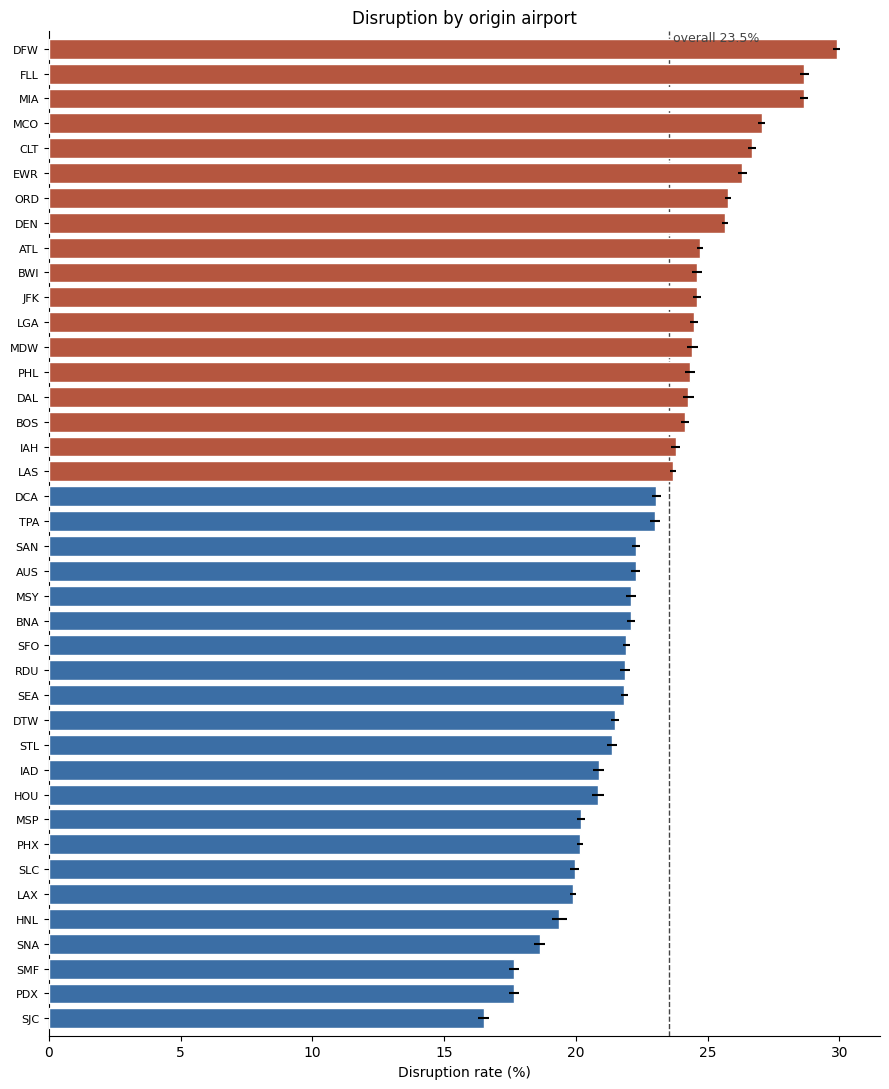

In [7]:
a = pd.read_parquet(DATA_PATH, columns=["Origin", TARGET_COL])
ap = add_ci_lift(a.groupby("Origin")[TARGET_COL].agg(rate="mean", k="sum", n="count").sort_values("rate"))

fig, ax = plt.subplots(figsize=(9, 11))
y = np.arange(len(ap)); rates = ap["rate"].to_numpy() * 100
xerr = np.vstack([(ap["rate"]-ap["ci_low"]).to_numpy(), (ap["ci_high"]-ap["rate"]).to_numpy()]) * 100
colors = ["#b5563f" if r > base_rate else "#3b6ea5" for r in ap["rate"]]
ax.barh(y, rates, xerr=xerr, color=colors, edgecolor="white", zorder=3)
ax.axvline(base_rate*100, ls="--", lw=1, color="#444", zorder=2)
ax.text(base_rate*100, len(ap)-0.3, f" overall {base_rate*100:.1f}%", color="#444", va="top", fontsize=9)
ax.set_yticks(y); ax.set_yticklabels(ap.index, fontsize=8); ax.set_ylim(-0.7, len(ap)-0.3)
ax.set_xlabel("Disruption rate (%)"); ax.set_title("Disruption by origin airport")
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout(); plt.show()

**The worst airports are a weather map, not a congestion map.** Disruption ranges from ~17% (San Jose) to ~30% (Dallas/Fort Worth). The hardest airports cluster in **thunderstorm country** (Dallas, the Florida airports, Charlotte) plus a couple of notorious hubs (Newark, Chicago); the easiest are in **dry, stable climates** (the West Coast, Southwest, and Hawaii). Tellingly, Atlanta — the world's busiest airport — is only slightly above average, which suggests that that sheer traffic volume isn't the culprit.

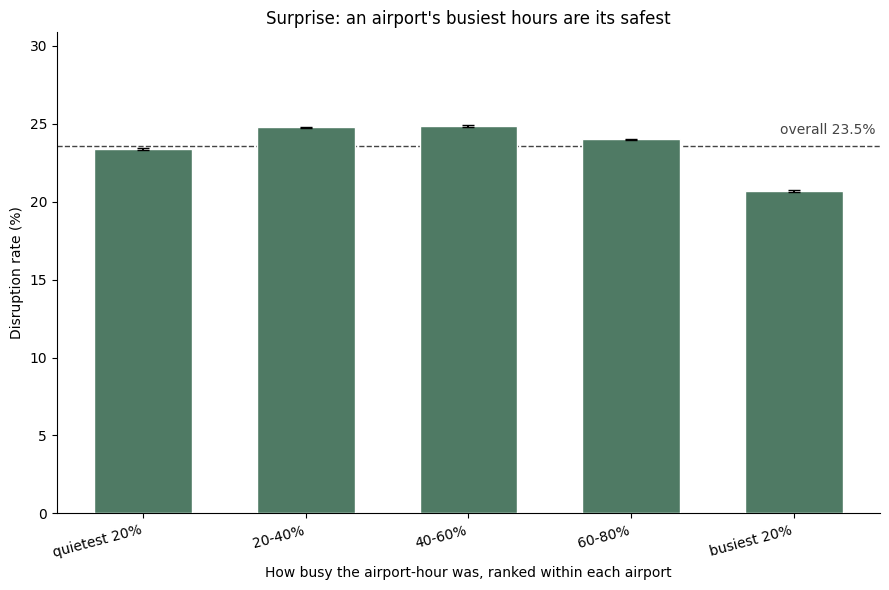

In [8]:
b = pd.read_parquet(DATA_PATH, columns=["Origin", "FlightDate", "CRSDepTime", TARGET_COL])
b = b[b["CRSDepTime"].notna()].copy()
b["hour"] = (b["CRSDepTime"].astype(int)//100) % 24

# How many flights share the same airport, same local hour, same day.
b["load"] = b.groupby(["Origin", "FlightDate", "hour"])["Origin"].transform("size")
# Rank each hour's load WITHIN its airport, so airport size doesn't dominate.
b["load_pct"] = b.groupby("Origin")["load"].rank(pct=True)
b["load_bin"] = pd.cut(b["load_pct"], [0, 0.2, 0.4, 0.6, 0.8, 1.0],
                       labels=["quietest 20%", "20-40%", "40-60%", "60-80%", "busiest 20%"],
                       include_lowest=True)
lb = add_ci_lift(b.groupby("load_bin", observed=True)[TARGET_COL].agg(rate="mean", k="sum", n="count"))

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(lb)); rates = lb["rate"].to_numpy() * 100
yerr = np.vstack([(lb["rate"]-lb["ci_low"]).to_numpy(), (lb["ci_high"]-lb["rate"]).to_numpy()]) * 100
ax.bar(x, rates, 0.6, yerr=yerr, capsize=4, color="#4f7a64", edgecolor="white", zorder=3)
ax.axhline(base_rate*100, ls="--", lw=1, color="#444", zorder=2)
ax.text(len(lb)-0.5, base_rate*100+0.8, f"overall {base_rate*100:.1f}%", ha="right", color="#444")
ax.set_xticks(x); ax.set_xticklabels(lb.index, rotation=15, ha="right")
ax.set_xlabel("How busy the airport-hour was, ranked within each airport")
ax.set_ylabel("Disruption rate (%)")
ax.set_title("Surprise: an airport's busiest hours are its safest")
ax.set_ylim(0, max(rates)+6)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout(); plt.show()

**Congestion, surprisingly, is not a driver.** We ranked each airport's hours from quietest to busiest (so airport size doesn't skew it) and asked whether busier hours are more disrupted. The **busiest hours are actually the *safest*.** The hypothesized reason: an airport's busiest hours are its well-planned morning departure banks, which fall early in the day when disruption is lowest. The time-of-day effect simply overwhelms any crowding effect, so a naive "flights per hour" feature would be misleading.

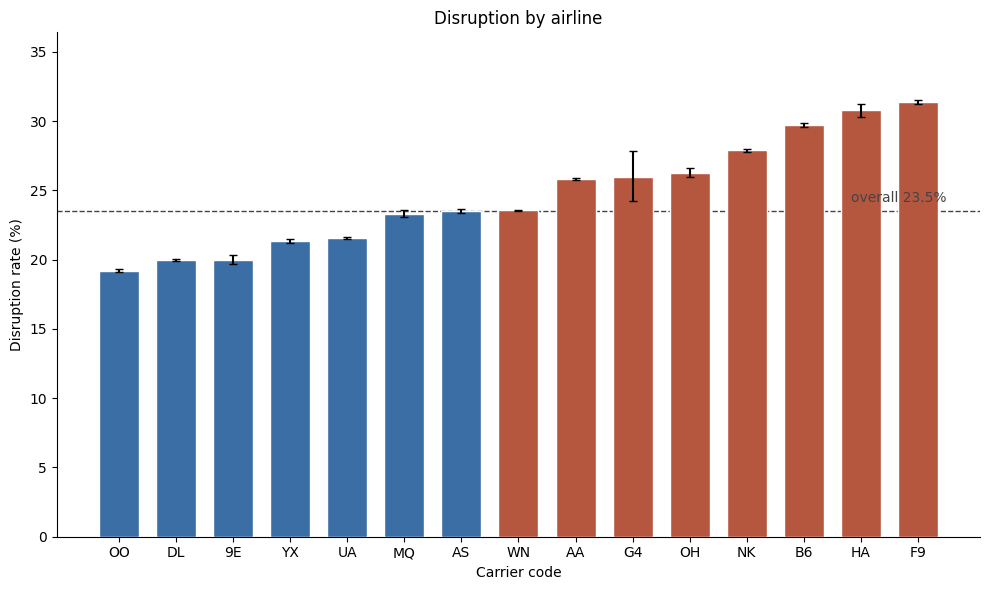

In [9]:
s = pd.read_parquet(DATA_PATH, columns=["Reporting_Airline", "FlightDate", TARGET_COL])
fd = pd.to_datetime(s["FlightDate"])
s["dow"]   = fd.dt.dayofweek      # 0=Mon ... 6=Sun
s["month"] = fd.dt.month          # 1..12

def grouped(by):
    return add_ci_lift(s.groupby(by, observed=True)[TARGET_COL].agg(rate="mean", k="sum", n="count"))

def bar_rate(t, labels, title, xlabel):
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(t)); rates = t["rate"].to_numpy() * 100
    yerr = np.vstack([(t["rate"]-t["ci_low"]).to_numpy(), (t["ci_high"]-t["rate"]).to_numpy()]) * 100
    colors = ["#b5563f" if r > base_rate else "#3b6ea5" for r in t["rate"]]
    ax.bar(x, rates, 0.7, yerr=yerr, capsize=3, color=colors, edgecolor="white", zorder=3)
    ax.axhline(base_rate*100, ls="--", lw=1, color="#444", zorder=2)
    ax.text(len(t)-0.5, base_rate*100+0.6, f"overall {base_rate*100:.1f}%", ha="right", color="#444")
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_xlabel(xlabel); ax.set_ylabel("Disruption rate (%)"); ax.set_title(title)
    ax.set_ylim(0, max(rates)+5); ax.spines[["top","right"]].set_visible(False)
    fig.tight_layout(); plt.show()

car = grouped("Reporting_Airline").sort_values("rate")
bar_rate(car, car.index, "Disruption by airline", "Carrier code")

**Airline rankings are mostly geography.** A carrier inherits the climate of the airports it flies from. For instance, American (AA) looks worse partly because it's concentrated at storm-prone Dallas, Charlotte, and Miami; Delta (DL) looks better partly because of its efficient hubs. On top of that, two real operational signals stand out: the budget carriers Frontier (F9), Spirit (NK), and JetBlue (B6) run tight schedules with no slack to recover from a hiccup, and Hawaiian (HA) is a striking outlier — near the worst *despite* Hawaii's calm weather, pointing to a small fleet stretched thin across long routes. *(Codes like OO, 9E, YX, MQ, OH are regional airlines flying under the big brands.)*

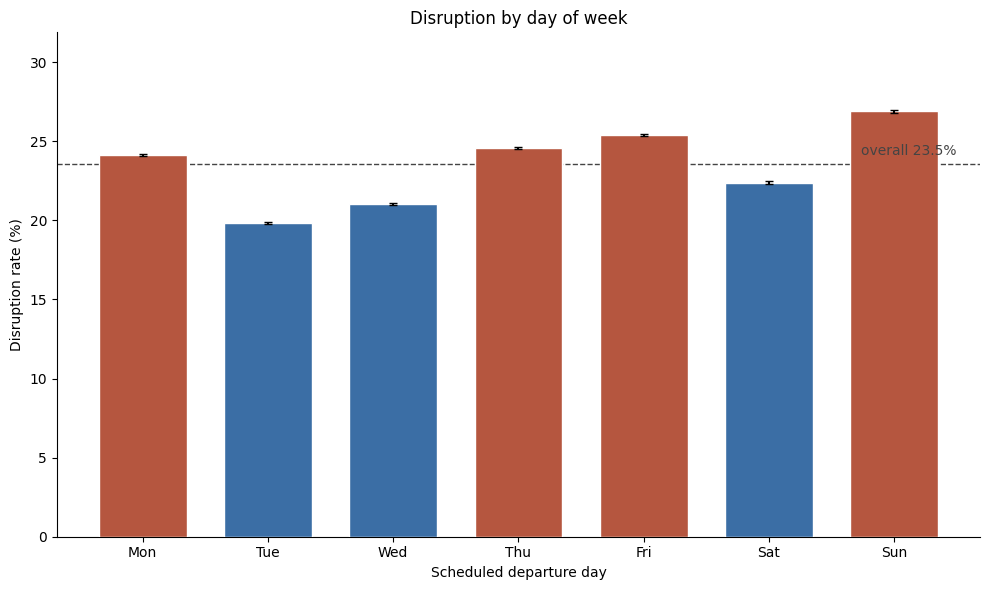

In [10]:
dow = grouped("dow").reindex(range(7))
bar_rate(dow, ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"],
         "Disruption by day of week", "Scheduled departure day")

**Mid-week is calmest; Sunday is worst.** Tuesday and Wednesday are the smoothest days to fly (~20%), while Sunday — peak return-travel day — is the most disrupted (~27%), with Friday close behind. The pattern follows travel demand, not weather.

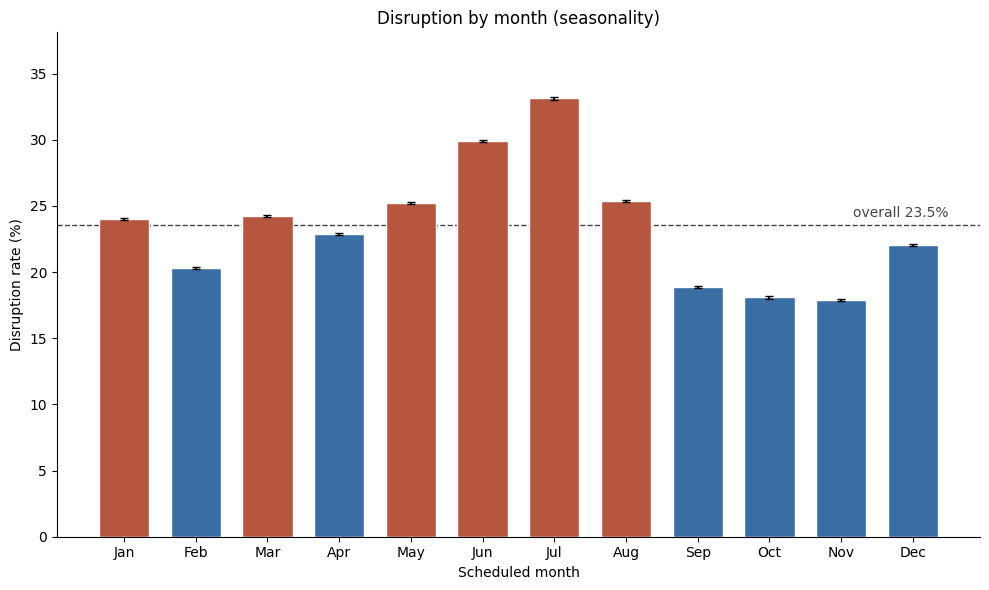

In [11]:
mon = grouped("month").reindex(range(1, 13))
bar_rate(mon, ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
         "Disruption by month (seasonality)", "Scheduled month")

**Summer, not winter, is the disruption season.** The clear peak is **July (~33%)**, driven by widespread afternoon **thunderstorms** plus heavy travel; fall (Sept–Nov) is the calmest stretch of the year. Winter is surprisingly mild with December and February sitting *below* average. This ties the whole analysis together: summer storms are widespread and hit a huge share of flights, while snow, though severe, is rare and geographically concentrated, so it barely moves the yearly average.

## Takeaways

**Strongest predictors of disruption, roughly in order**

1. **Inbound (knock-on) delay** — by far the strongest single signal.
2. **Time of year** — summer thunderstorm season dominates.
3. **Origin airport** — a climate-and-structure fingerprint.
4. **Time of day** — delays compound from morning to evening.
5. **Origin weather** — snow (rare but severe) and wind (common but milder); the departure side matters more.
6. **Airline and day of week** — secondary, but real.

**Two things that didn't work as expected**

- Raw airport "congestion" (flights per hour) does **not** predict disruption.
- Total cloud cover is too crude to capture the low-ceiling conditions that actually disrupt flights, so we set did not conduct an exploration.